# Edge Cases: Repairing Disconnected Contours
This notebook specifically re-processes patient IDs where the clinician's bounding box wasn't fully closed.
By applying a much larger morphological closing matrix, we forcefully bridge those gaps before filling the mask.

In [1]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import cv2

input_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2")
output_directory = os.path.join("..", "data", "PANCREAS_EDGE_CASES_FIXED")

os.makedirs(os.path.join(output_directory, "masks"), exist_ok=True)
os.makedirs(os.path.join(output_directory, "segmented"), exist_ok=True)

outliers = ["03_01", "43_01"]

# This kernel will act like a thick brush to close the wide gaps in the doctors lines.
closing_kernel_size = 35 
color_threshold = 200

# The standard final erosion we agreed on
erosion_kernel = np.ones((3, 3), np.uint8)

print(f"Set up to process {outliers} with a {closing_kernel_size}x{closing_kernel_size} closing brush.")

Set up to process ['03_01', '43_01'] with a 35x35 closing brush.


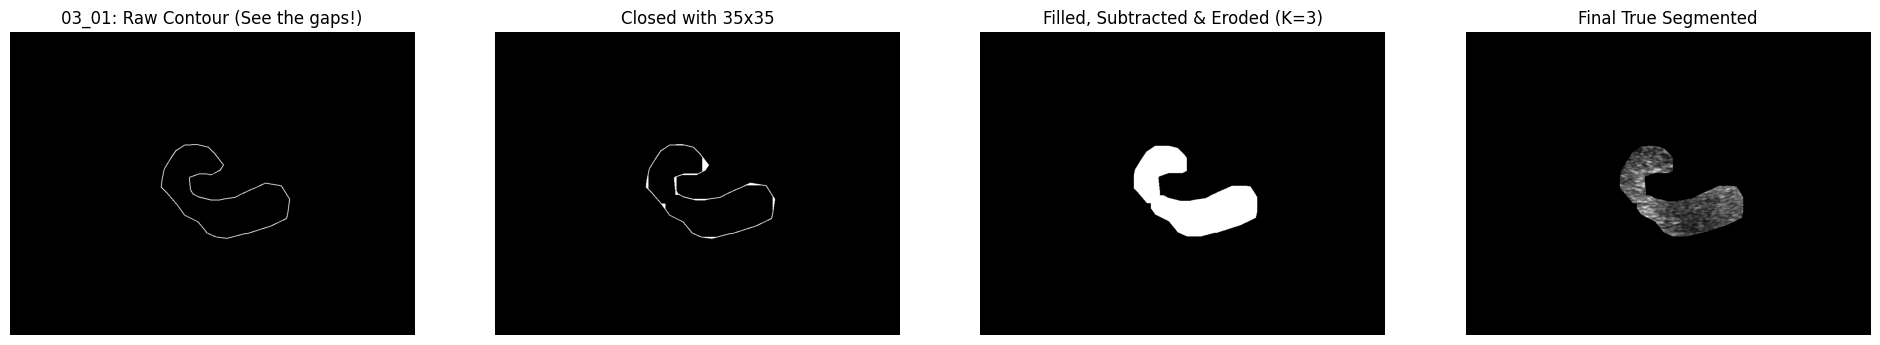

Successfully successfully fixed and saved outputs for 03_01.


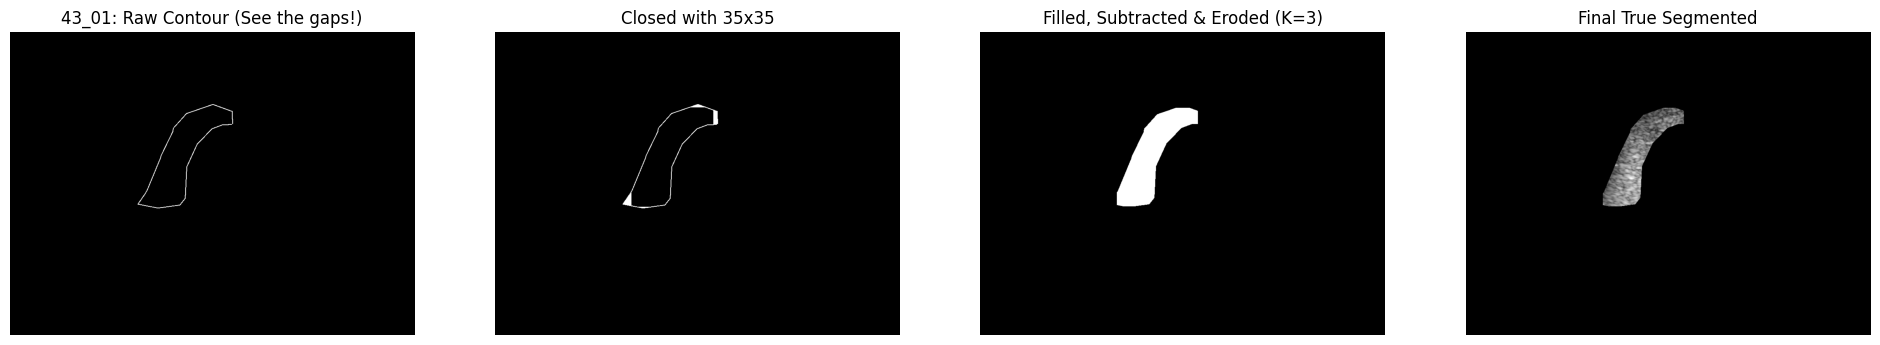

Successfully successfully fixed and saved outputs for 43_01.


In [2]:
for study_id in outliers:
    study_path = os.path.join(input_directory, study_id)
    
    date_folders = [f for f in os.listdir(study_path) if not f.startswith(".")]
    if not date_folders: continue
    
    date_path = os.path.join(study_path, date_folders[0])
    files = [f for f in os.listdir(date_path) if not f.startswith(".")]
    if not files: continue
        
    dicom_path = os.path.join(date_path, files[0])
    
    # 1. Load Original DICOM
    dataset = pydicom.dcmread(dicom_path)
    image_rgb = dataset.pixel_array
    
    # 2. Extract raw white clinician boundary mask
    white_mask = (image_rgb[:, :, 0] > color_threshold) & \
                 (image_rgb[:, :, 1] > color_threshold) & \
                 (image_rgb[:, :, 2] > color_threshold)
    white_mask_8bit = (white_mask * 255).astype(np.uint8)
    
    # 3. Clean up UI noise - Keep only the largest white island (which is the boundary box)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)
    largest_label = 1
    max_area = 0
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > max_area:
            max_area = area
            largest_label = i
            
    clean_contour = np.zeros_like(white_mask_8bit)
    if max_area > 0:
        clean_contour[labels == largest_label] = 255
        
    # 4. BRUSH: Close gaps with the massively huge 35x35 closing kernel
    brush_kernel = np.ones((closing_kernel_size, closing_kernel_size), np.uint8)
    closed_contour = cv2.morphologyEx(clean_contour, cv2.MORPH_CLOSE, brush_kernel)
    
    # 5. Fill the fully closed contour loop to create the solid mass
    contours, _ = cv2.findContours(closed_contour, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(closed_contour)
    cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)
    
    # 6. Subtract the FAT closed outline from our filled mass so we get just the pancreas interior
    # This acts as our contour subtraction
    clean_mask = filled_mask.copy()
    clean_mask[closed_contour > 0] = 0
    
    # 7. Apply the final gentle K=3 Erosion (same as `09`)
    final_eroded_mask = cv2.erode(clean_mask, erosion_kernel, iterations=1)
    
    # 8. Create the final black segmented preview image
    gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    
    # Create the segmented overlay
    segmented_image = cv2.bitwise_and(gray_image, gray_image, mask=final_eroded_mask)

    # 9. Plot the stages so you can visually verify the gaps closed
    plt.figure(figsize=(24, 6))
    
    plt.subplot(1, 4, 1)
    plt.imshow(clean_contour, cmap='gray')
    plt.title(f"{study_id}: Raw Contour (See the gaps!)")
    plt.axis("off")
    
    plt.subplot(1, 4, 2)
    plt.imshow(closed_contour, cmap='gray')
    plt.title(f"Closed with {closing_kernel_size}x{closing_kernel_size}")
    plt.axis("off")
    
    plt.subplot(1, 4, 3)
    plt.imshow(final_eroded_mask, cmap='gray')
    plt.title(f"Filled, Subtracted & Eroded (K=3)")
    plt.axis("off")
    
    plt.subplot(1, 4, 4)
    plt.imshow(segmented_image, cmap='gray')
    plt.title(f"Final True Segmented")
    plt.axis("off")
    
    plt.show()
    
    # Save the output to disk so you have them
    mask_save_path = os.path.join(output_directory, "masks", f"{study_id}_k3_i1_mask.png")
    image_save_path = os.path.join(output_directory, "segmented", f"{study_id}_k3_i1_segmented.png")
    
    cv2.imwrite(mask_save_path, final_eroded_mask)
    cv2.imwrite(image_save_path, segmented_image)
    
    print(f"Successfully successfully fixed and saved outputs for {study_id}.")